In [2]:
# 1. Import Libraries

import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist
from tensorflow.keras import layers, Sequential

In [ ]:
# 2. Load MNIST Dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

print("Training data:", x_train.shape)
print("Testing data:", x_test.shape)

Training data: (60000, 28, 28)
Testing data: (10000, 28, 28)


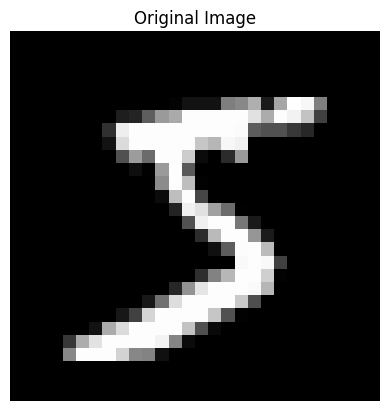

In [ ]:
# 3. Show Original Image
image = x_train[0]

plt.imshow(image, cmap="gray")
plt.title("Original Image")
plt.axis("off")
plt.show()

In [ ]:
# 4. Add Noise to One Image
noise = np.random.normal(
    0,
    50,
    image.shape
)
noisy_image = image + noise

# Keep pixel values between 0 and 255
noisy_image = np.clip(
    noisy_image,
    0,
    255
)

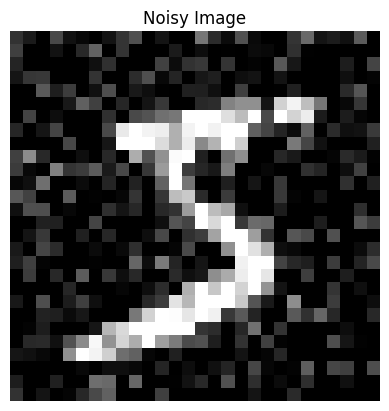

In [ ]:
# Show Noisy Image
plt.imshow(noisy_image, cmap="gray")
plt.title("Noisy Image")
plt.axis("off")
plt.show()


In [ ]:
# 5. Prepare Training Data
# Convert pixel values from 0-255 to 0-1

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

In [ ]:
# Add channel dimension
x_train = x_train[..., np.newaxis]
x_test = x_test[..., np.newaxis]

print("New shape:", x_train.shape)

New shape: (60000, 28, 28, 1)


In [ ]:
# 6. Create Noisy Training Images
noise = np.random.normal(
    0,
    0.3,
    x_train.shape
)
x_train_noisy = x_train + noise

# Keep values between 0 and 1
x_train_noisy = np.clip(
    x_train_noisy,
    0,
    1
)


In [ ]:
# 7. Create Denoising Model
model = Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, 3, activation="relu", padding="same"),
    layers.Conv2D(32, 3, activation="relu", padding="same"),
    layers.Conv2D(1, 3, activation="sigmoid", padding="same")])


In [ ]:
# 8. Compile Model
model.compile(
    optimizer="adam",
    loss="mse"
)

In [ ]:
# 9. See Model
model.summary()


# 10. Train Model
model.fit(
    x_train_noisy,
    x_train,
    epochs=5,
    batch_size=128
)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,857 (38.50 KB)

 Trainable params: 9,857 (38.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 24s 47ms/step - loss: 0.0210
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 20s 42ms/step - loss: 0.0059
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 23s 49ms/step - loss: 0.0056
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 20s 43ms/step - loss: 0.0054
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 21s 45ms/step - loss: 0.0053


In [13]:
# 11. Prepare Our Original Noisy Image

noisy_image_input = noisy_image / 255.0

noisy_image_input = noisy_image_input[
    np.newaxis,
    ...,
    np.newaxis
]

In [14]:
# 12. Remove Noise

denoised_image = model.predict(
    noisy_image_input
)


# Remove extra dimensions

denoised_image = denoised_image[0].squeeze()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 285ms/step


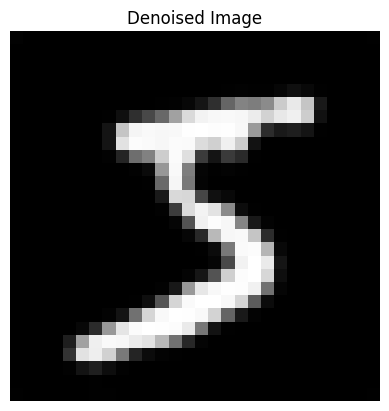

In [15]:
# 13. Show Denoised Image

plt.imshow(
    denoised_image,
    cmap="gray"
)

plt.title("Denoised Image")
plt.axis("off")
plt.show()


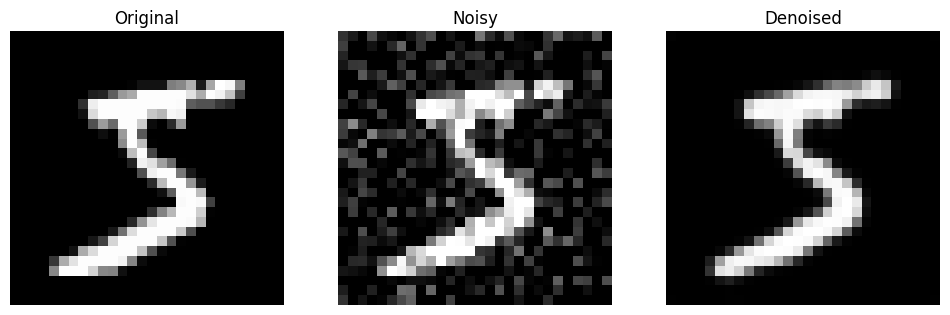

In [16]:
# 14. Show All Three Together

plt.figure(figsize=(12, 4))


# Original
plt.subplot(1, 3, 1)
plt.imshow(image, cmap="gray")
plt.title("Original")
plt.axis("off")


# Noisy
plt.subplot(1, 3, 2)
plt.imshow(noisy_image, cmap="gray")
plt.title("Noisy")
plt.axis("off")


# Denoised
plt.subplot(1, 3, 3)
plt.imshow(denoised_image, cmap="gray")
plt.title("Denoised")
plt.axis("off")


plt.show()